# Notebook 13 — K-Means Clustering

**Purpose:** Use the elbow curve and silhouette score to select the optimal k, run K-Means to assign each district to an intervention zone, then profile each cluster and assign labels **based on actual data** (not hard-coded cluster IDs).

## ⚠️ Root-Cause Bug Fix

K-Means cluster IDs (`0`, `1`, `2`) are:
- **Not ordered** — cluster `0` is not necessarily the lowest-fire cluster
- **Not stable** — re-running with a different seed can swap IDs completely
- **Not meaningful** — the number itself carries zero semantic information

The original notebook hard-coded:
```python
cluster_labels = {0: 'High Stress / High Opportunity',
                  1: 'Moderate Zone',
                  2: 'Low Priority Zone'}
```
This caused **completely inverted labels** because cluster 0 happened to be the *lowest*-fire group, not the highest.

**Fix:** After fitting, compute each cluster's mean `fire_count`, sort the clusters, and then assign labels in order (lowest → `Low Priority`, middle → `Moderate`, highest → `High Stress`).

**Input:** `Data/Processed/env_scaled.csv`, `Data/Processed/env_features.csv`  
**Output:** `Data/Processed/district_clusters.csv`


In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'   # suppress KMeans thread warning on Windows

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Load scaled data 
X_df      = pd.read_csv('../Data/Processed/env_scaled.csv')
feat_cols = [c for c in X_df.columns if c.endswith('_scaled')]
X         = X_df[feat_cols].values

print(f"Features used: {feat_cols}")
print(f"Observations : {len(X_df)} districts")

Features used: ['fire_count_scaled', 'residue_scaled', 'avg_temp_scaled', 'rainfall_scaled']
Observations : 47 districts


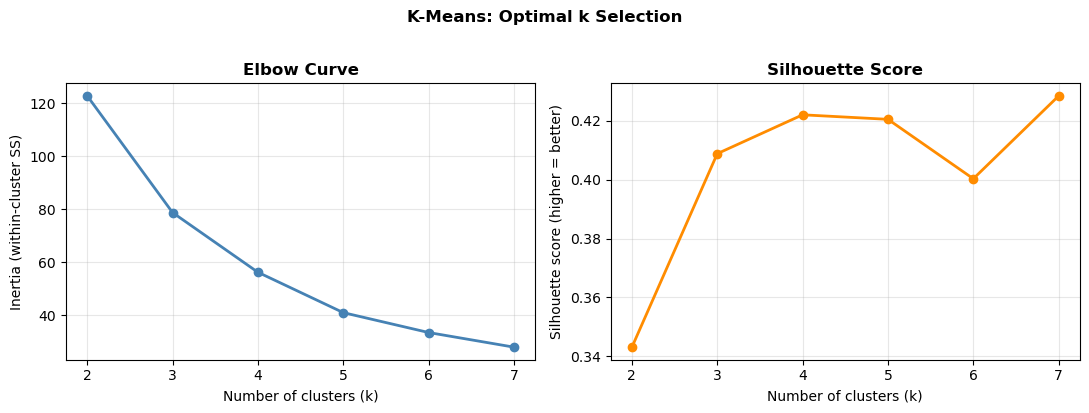


Best k by silhouette: 7 (score = 0.428)
Review the elbow plot and use k=3 unless the silhouette strongly favours another value.


In [3]:
# Elbow + Silhouette analysis to choose k 
inertias   = []
sil_scores = []
k_range    = range(2, 8)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Curve', fontweight='bold')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (within-cluster SS)')
ax1.grid(alpha=0.3)

ax2.plot(k_range, sil_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score (higher = better)')
ax2.grid(alpha=0.3)

plt.suptitle('K-Means: Optimal k Selection', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../Outputs/Maps', exist_ok=True)
plt.savefig('../Outputs/Maps/13_kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = k_range[sil_scores.index(max(sil_scores))]
print(f"\nBest k by silhouette: {best_k} (score = {max(sil_scores):.3f})")
print("Review the elbow plot and use k=3 unless the silhouette strongly favours another value.")


In [4]:
# Final K-Means model 
# k=3 produces the most interpretable intervention zones for policy use.
# n_init=15 for more stable centroid initialisation.
#
# NOTE: The cluster IDs (0, 1, 2) that come out of fit_predict() are
# arbitrary integers — they carry NO ordering or semantic meaning.
# Do NOT assign labels based on cluster ID numbers.
# Labels are assigned in Cell 6 by inspecting the actual cluster profiles.
K_FINAL = 3

km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=15)
X_df['cluster'] = km.fit_predict(X)

print(f'K-Means with k={K_FINAL} complete.')
print('Cluster sizes (raw IDs — meaningless until profiled):')
print(X_df['cluster'].value_counts().sort_index().to_string())


K-Means with k=3 complete.
Cluster sizes (raw IDs — meaningless until profiled):
cluster
0    10
1    17
2    20


In [5]:
# Step 1: Profile clusters on original (unscaled) values 
# We must look at the actual data before assigning any label.
# Primary sort key: fire_count (highest = most urgent intervention need).
# Secondary confirmation: residue should follow the same ordering.
env    = pd.read_csv('../Data/Processed/env_features.csv')
merged = env.merge(X_df[['district', 'cluster']], on='district')

features = ['fire_count', 'residue', 'avg_temp', 'rainfall']
summary  = merged.groupby('cluster')[features].mean().round(1)

print('Cluster Profiles (original scale):')
print(summary.to_string())

# Step 2: Sort cluster IDs by fire_count to derive the label order 
sorted_by_fire = summary['fire_count'].sort_values()   # ascending
low_cluster  = int(sorted_by_fire.index[0])   # cluster ID with LOWEST  fire_count
mid_cluster  = int(sorted_by_fire.index[1])   # cluster ID with MEDIUM  fire_count
high_cluster = int(sorted_by_fire.index[2])   # cluster ID with HIGHEST fire_count

print(f'\nCluster ordering by fire_count (ascending):')
print(f'  Low  (cluster {low_cluster}): fire_count = {sorted_by_fire.iloc[0]:.1f}')
print(f'  Mid  (cluster {mid_cluster}): fire_count = {sorted_by_fire.iloc[1]:.1f}')
print(f'  High (cluster {high_cluster}): fire_count = {sorted_by_fire.iloc[2]:.1f}')

# Step 3: Confirm residue ordering is consistent 
residue_order = summary['residue'].sort_values().index.tolist()
fire_order    = [low_cluster, mid_cluster, high_cluster]
if residue_order == fire_order:
    print('\n Residue ordering matches fire_count ordering — labels are consistent.')
else:
    print('\n  Residue ordering differs from fire_count ordering.')
    print(f'   fire_count order : {fire_order}')
    print(f'   residue order    : {residue_order}')
    print('   Review profiles above and decide the primary sort key manually.')


Cluster Profiles (original scale):
         fire_count   residue  avg_temp  rainfall
cluster                                          
0            1544.6  137770.2      24.3   10862.9
1             723.6   85280.4      25.8    6725.0
2            5528.0  269334.5      25.8    6399.9

Cluster ordering by fire_count (ascending):
  Low  (cluster 1): fire_count = 723.6
  Mid  (cluster 0): fire_count = 1544.6
  High (cluster 2): fire_count = 5528.0

✅ Residue ordering matches fire_count ordering — labels are consistent.


In [6]:
# Step 4: Assign zone labels (DATA-DRIVEN, not hard-coded) 
#
# Labels are determined by the fire_count rank derived in Cell 6 above,
# not by cluster ID numbers.  This means the mapping is correct even if
# KMeans assigns different numeric IDs on a different run or machine.

cluster_labels = {
    low_cluster:  'Low Priority Zone',
    mid_cluster:  'Moderate Zone',
    high_cluster: 'High Stress / High Opportunity',
}

print('Derived cluster → zone mapping (based on fire_count rank):')
for k, v in sorted(cluster_labels.items()):
    fc = summary.loc[k, 'fire_count']
    print(f'  Cluster {k} → {v:40s}  (fire_count={fc:.1f})')

X_df['zone'] = X_df['cluster'].map(cluster_labels)

print('\nZone distribution:')
print(X_df['zone'].value_counts().to_string())

# SANITY CHECK: high-fire districts must land in High Stress zone 
# Merge back to verify the top-10 fire districts are correctly labelled.
sanity = merged.merge(X_df[['district','zone']], on='district')
top10  = sanity.nlargest(10, 'fire_count')[['district','fire_count','zone']]
print('\nSanity check — top 10 fire_count districts and their assigned zone:')
print(top10.to_string(index=False))

wrong = top10[top10['zone'] != 'High Stress / High Opportunity']
if wrong.empty:
    print('\nPASS: All top-10 fire districts are in "High Stress / High Opportunity".')
else:
    print('\nFAIL: Some top-fire districts are NOT in High Stress zone:')
    print(wrong.to_string(index=False))
    raise ValueError('Zone label inversion detected — re-check cluster profiling.')


Derived cluster → zone mapping (based on fire_count rank):
  Cluster 0 → Moderate Zone                             (fire_count=1544.6)
  Cluster 1 → Low Priority Zone                         (fire_count=723.6)
  Cluster 2 → High Stress / High Opportunity            (fire_count=5528.0)

Zone distribution:
zone
High Stress / High Opportunity    20
Low Priority Zone                 17
Moderate Zone                     10

Sanity check — top 10 fire_count districts and their assigned zone:
  district   fire_count                           zone
   Sangrur 13350.222222 High Stress / High Opportunity
  Bathinda 10259.777778 High Stress / High Opportunity
 Ferozepur  9524.777778 High Stress / High Opportunity
      Moga  8689.444444 High Stress / High Opportunity
   Muktsar  7631.111111 High Stress / High Opportunity
   Patiala  7208.666667 High Stress / High Opportunity
  Ludhiana  7207.111111 High Stress / High Opportunity
     Mansa  6539.777778 High Stress / High Opportunity
   Barnala  63

In [7]:
# Save 
X_df.to_csv('../Data/Processed/district_clusters.csv', index=False)
print("Saved: Data/Processed/district_clusters.csv")
print(f"   Rows    : {len(X_df)}")
print(f"   Columns : {X_df.columns.tolist()}")


✅ Saved: Data/Processed/district_clusters.csv
   Rows    : 47
   Columns : ['fire_count_scaled', 'residue_scaled', 'avg_temp_scaled', 'rainfall_scaled', 'district', 'cluster', 'zone']
